In [1]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ANNOTATION = Path(
    "Output_files/official_57_sample/annotated.gtf.gz"
)

OUT_DIR = Path(
    "Output_files/official_57_sample"
)

FIG_DIR = Path(
    "Figures/official_57_sample"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Two non-RNA-seq columns in the native index
EXCLUDE_SAMPLES = [
    "SRR6713217",
    "SRR6713218"
]

EXPECTED_SAMPLES = 57

In [3]:
def inspect_header(path):

    sample_names = []
    header_line = None

    with gzip.open(path, "rt") as f:

        for i, line in enumerate(f):

            if (
                line.startswith("##[SAMPLE]")
                and not line.startswith("##[SAMPLE]Sample")
            ):
                sample = (
                    line.split("\t", 1)[0]
                    .replace("##[SAMPLE]", "")
                    .strip()
                )

                sample_names.append(sample)

            elif line.startswith("#chrom\t"):

                header_line = i
                columns = line.rstrip("\n").split("\t")
                break

    if header_line is None:
        raise ValueError("Could not find #chrom header")

    return header_line, sample_names, columns

In [4]:
header_line, native_samples, columns = inspect_header(
    ANNOTATION
)

print("Native sample columns:", len(native_samples))
print(native_samples[:10])

Native sample columns: 59
['SRR17660891', 'SRR17660893', 'SRR17660908', 'SRR17660909', 'SRR17660910', 'SRR17660911', 'SRR17660912', 'SRR17660913', 'SRR17660914', 'SRR17660915']


In [5]:
samples = [
    sample
    for sample in native_samples
    if sample not in EXCLUDE_SAMPLES
]

print("RNA-seq samples:", len(samples))

assert len(samples) == EXPECTED_SAMPLES

RNA-seq samples: 57


In [6]:
annotation = pd.read_csv(
    ANNOTATION,
    sep="\t",
    skiprows=header_line,
    low_memory=False
)

print("Transcripts:", len(annotation))
print("Columns:", len(annotation.columns))

display(annotation.head())

Transcripts: 102140
Columns: 72


,#chrom,start,end,length,exon_count,trans_id,gene_id,ranking_score,detected(total:fsm:em),min_read,...,SRR6039167,SRR6039168,SRR6039169,SRR6039170,SRR6039171,SRR6039172,SRR6039173,SRR6039174,SRR6713217,SRR6713218
0,1,14045,16939,2216,4,ENSPTRT00045018136,ENSPTRG00045009616,0.0,no:no:no,1,...,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0
1,1,14137,16573,2340,2,ENSPTRT00045018131,ENSPTRG00045009616,0.0,no:no:no,1,...,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0
2,1,14137,16573,1757,4,ENSPTRT00045018135,ENSPTRG00045009616,0.0,no:no:no,1,...,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0
3,1,17005,103870,1567,10,ENSPTRT00045019377,ENSPTRG00045010313,0.0,no:no:no,1,...,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0
4,1,17742,21633,726,3,ENSPTRT00045019383,ENSPTRG00045010313,0.0,no:no:no,1,...,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0,0:0:0:0:0:0


In [7]:
def parse_sample_column(series):

    parts = (
        series
        .fillna("0:0:0:0:0:0")
        .astype(str)
        .str.split(":", expand=True)
    )

    if parts.shape[1] < 6:
        raise ValueError(
            "Sample field has fewer than 6 components"
        )

    values = (
        parts.iloc[:, :6]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy()
    )

    return values

In [8]:
n_transcripts = len(annotation)
n_samples = len(samples)

cpm = np.zeros(
    (n_transcripts, n_samples)
)

read_count = np.zeros(
    (n_transcripts, n_samples)
)

fsm_count = np.zeros(
    (n_transcripts, n_samples)
)

em_count = np.zeros(
    (n_transcripts, n_samples)
)

In [9]:
for j, sample in enumerate(samples):

    values = parse_sample_column(
        annotation[sample]
    )

    cpm[:, j] = values[:, 0]

    read_count[:, j] = values[:, 1]

    fsm_count[:, j] = values[:, 3]

    em_count[:, j] = values[:, 5]

In [10]:
detected_matrix = (
    (read_count > 0)
    | (fsm_count > 0)
    | (em_count > 0)
)

positive_total = (
    detected_matrix.sum(axis=1)
)

positive_fsm = (
    (fsm_count > 0).sum(axis=1)
)

positive_em = (
    (em_count > 0).sum(axis=1)
)

In [11]:
population_frequency = (
    positive_total / n_samples
)

fsm_population_frequency = (
    positive_fsm / n_samples
)

em_population_frequency = (
    positive_em / n_samples
)

In [12]:
mean_cpm = cpm.mean(axis=1)

median_cpm = np.median(
    cpm,
    axis=1
)

max_cpm = cpm.max(axis=1)

In [13]:
positive_cpm_samples = (
    cpm > 0
).sum(axis=1)

mean_positive_cpm = np.divide(
    cpm.sum(axis=1),
    positive_cpm_samples,
    out=np.zeros(n_transcripts),
    where=positive_cpm_samples > 0
)

In [14]:
total_read_count = (
    read_count.sum(axis=1)
)

total_fsm_count = (
    fsm_count.sum(axis=1)
)

total_em_count = (
    em_count.sum(axis=1)
)

In [15]:
identifier_columns = [
    x for x in [
        "#chrom",
        "chrom",
        "start",
        "end",
        "length",
        "exon_count",
        "trans_id",
        "gene_id",
        "ranking_score"
    ]
    if x in annotation.columns
]

In [16]:
summary = annotation[
    identifier_columns
].copy()

summary = summary.rename(
    columns={"#chrom": "chrom"}
)

In [18]:
summary["detected_total"] = (
    positive_total > 0
)

summary["detected_fsm"] = (
    positive_fsm > 0
)

summary["detected_em"] = (
    positive_em > 0
)

summary["positive_total"] = positive_total

summary["positive_fsm"] = positive_fsm

summary["positive_em"] = positive_em

summary["sample_size"] = n_samples

In [19]:
summary["population_frequency"] = (
    population_frequency
)

summary["fsm_population_frequency"] = (
    fsm_population_frequency
)

summary["em_population_frequency"] = (
    em_population_frequency
)

In [20]:
summary["mean_cpm"] = mean_cpm

summary["median_cpm"] = median_cpm

summary["max_cpm"] = max_cpm

summary["mean_positive_cpm"] = (
    mean_positive_cpm
)

summary["total_read_count"] = (
    total_read_count
)

summary["total_fsm_count"] = (
    total_fsm_count
)

summary["total_em_count"] = (
    total_em_count
)

In [21]:
display(summary.head())

,chrom,start,end,length,exon_count,trans_id,gene_id,ranking_score,detected_total,detected_fsm,...,population_frequency,fsm_population_frequency,em_population_frequency,mean_cpm,median_cpm,max_cpm,mean_positive_cpm,total_read_count,total_fsm_count,total_em_count
0,1,14045,16939,2216,4,ENSPTRT00045018136,ENSPTRG00045009616,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,14137,16573,2340,2,ENSPTRT00045018131,ENSPTRG00045009616,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,14137,16573,1757,4,ENSPTRT00045018135,ENSPTRG00045009616,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,17005,103870,1567,10,ENSPTRT00045019377,ENSPTRG00045010313,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,17742,21633,726,3,ENSPTRT00045019383,ENSPTRG00045010313,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
summary.to_csv(
    OUT_DIR
    / "transcript_population_expression.tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

In [23]:
def frequency_class(x):

    if x == 0:
        return "Not detected"

    elif x <= 0.10:
        return "Rare"

    elif x <= 0.25:
        return "Low frequency"

    elif x <= 0.50:
        return "Intermediate"

    elif x <= 0.90:
        return "Common"

    else:
        return "Core"

In [24]:
summary["frequency_class"] = (
    summary["population_frequency"]
    .apply(frequency_class)
)

summary["frequency_class"].value_counts()

frequency_class
Not detected     54565
Rare             30719
Intermediate      6654
Low frequency     6243
Common            3865
Core                94
Name: count, dtype: int64

In [25]:
summary.to_csv(
    OUT_DIR
    / "transcript_population_expression.tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

In [26]:
sample_summary = pd.DataFrame({

    "sample":
        samples,

    "detected_transcripts":
        detected_matrix.sum(axis=0),

    "summed_cpm":
        cpm.sum(axis=0),

    "total_read_count":
        read_count.sum(axis=0),

    "total_fsm_count":
        fsm_count.sum(axis=0),

    "total_em_count":
        em_count.sum(axis=0)
})

In [27]:
display(sample_summary.head())

,sample,detected_transcripts,summed_cpm,total_read_count,total_fsm_count,total_em_count
0,SRR17660891,14544,9.999965e+05,1.635869e+06,704486.0,931382.931086
1,SRR17660893,11620,1.000000e+06,8.233124e+05,356636.0,466676.408405
2,SRR17660908,8603,9.999975e+05,2.924568e+05,137835.0,154621.755769
3,SRR17660909,10930,9.999980e+05,3.193136e+05,77331.0,241982.608484
4,SRR17660910,8434,9.999965e+05,1.783552e+05,19059.0,159296.215053


In [28]:
sample_summary.to_csv(
    OUT_DIR
    / "sample_expression_summary.tsv",
    sep="\t",
    index=False
)

In [29]:
annotation_summary = pd.DataFrame([
    {
        "metric":
            "query_transcripts",

        "value":
            len(summary)
    },

    {
        "metric":
            "cohort_samples",

        "value":
            n_samples
    },

    {
        "metric":
            "detected_transcripts",

        "value":
            int(
                summary[
                    "detected_total"
                ].sum()
            )
    },

    {
        "metric":
            "detected_fraction",

        "value":
            summary[
                "detected_total"
            ].mean()
    },

    {
        "metric":
            "fsm_detected_transcripts",

        "value":
            int(
                summary[
                    "detected_fsm"
                ].sum()
            )
    },

    {
        "metric":
            "fsm_detected_fraction",

        "value":
            summary[
                "detected_fsm"
            ].mean()
    }
])

In [30]:
display(annotation_summary)

,metric,value
0,query_transcripts,102140.000000
1,cohort_samples,57.000000
2,detected_transcripts,47575.000000
3,detected_fraction,0.465782
4,fsm_detected_transcripts,42302.000000
5,fsm_detected_fraction,0.414157


In [31]:
annotation_summary.to_csv(
    OUT_DIR
    / "annotation_summary.tsv",
    sep="\t",
    index=False
)

In [32]:
top100 = (
    summary
    .sort_values(
        [
            "positive_total",
            "positive_fsm",
            "mean_cpm"
        ],
        ascending=False
    )
    .head(100)
)

In [33]:
display(top100.head(20))

,chrom,start,end,length,exon_count,trans_id,gene_id,ranking_score,detected_total,detected_fsm,...,fsm_population_frequency,em_population_frequency,mean_cpm,median_cpm,max_cpm,mean_positive_cpm,total_read_count,total_fsm_count,total_em_count,frequency_class
93290,9,14948845,14960954,3924,22,ENSPTRT00045037747,ENSPTRG00045019908,129.303233,True,True,...,0.403509,0.982456,1650.915052,388.301187,13684.768076,1680.395678,12852.254849,347.0,12505.254846,Core
19566,12,23741763,23804614,4883,24,ENSPTRT00045057307,ENSPTRG00045029644,34.830002,True,True,...,0.245614,0.982456,306.293965,185.011291,1768.317973,311.763500,5558.046801,296.0,5262.046800,Core
2203,1,62722133,62783650,7585,52,ENSPTRT00045090474,ENSPTRG00045046136,91.934727,True,False,...,0.000000,0.982456,642.645207,449.360874,3037.708793,654.121014,9757.062687,0.0,9757.062687,Core
101242,X,134312384,134319861,2225,9,ENSPTRT00045054624,ENSPTRG00045028504,92.092933,True,True,...,0.912281,0.824561,731.924865,489.613595,3678.658512,758.540314,11682.235621,9855.0,1827.235588,Core
10034,10,13717902,13721769,1282,9,ENSPTRT00045047144,ENSPTRG00045024546,366.230244,True,True,...,0.894737,0.912281,10885.672900,3300.236104,86536.345440,11281.515551,189501.994492,126313.0,63188.993641,Core
60831,22,29837758,29856036,2767,15,ENSPTRT00045016693,ENSPTRG00045008871,78.393043,True,True,...,0.771930,0.894737,1653.532540,460.331471,12936.548901,1713.660996,28547.480257,25160.0,3387.479955,Core
92015,8,131145078,131191086,5510,22,ENSPTRT00045042501,ENSPTRG00045022309,176.174979,True,True,...,0.403509,0.964912,948.794362,728.827460,3033.951083,983.295975,12269.280459,893.0,11376.280455,Core
40286,18,56522708,56633082,8574,49,ENSPTRT00045032093,ENSPTRG00045017039,105.900660,True,True,...,0.175439,0.964912,1165.422126,226.131710,9083.496792,1207.801112,4600.216718,243.0,4357.216688,Core
45675,19,77632685,77640584,3045,14,ENSPTRT00045033718,ENSPTRG00045017876,209.860562,True,True,...,0.070175,0.964912,1674.328323,1326.201781,6330.753344,1735.212990,30537.207123,8.0,30529.207123,Core
31948,15,100094369,100100739,3364,11,ENSPTRT00045058386,ENSPTRG00045030196,175.085205,True,True,...,0.070175,0.964912,1481.264206,646.247641,11282.676985,1535.128359,13528.895689,7.0,13521.895687,Core


In [34]:
top100.to_csv(
    OUT_DIR
    / "top_supported_transcripts.tsv",
    sep="\t",
    index=False
)

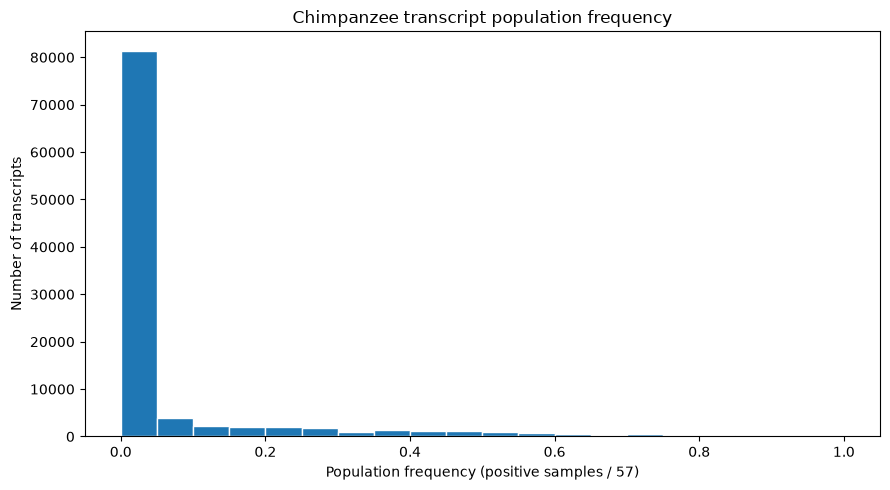

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(
    summary["population_frequency"],
    bins=np.linspace(0, 1, 21),
    edgecolor="white"
)

plt.xlabel(
    "Population frequency (positive samples / 57)"
)

plt.ylabel(
    "Number of transcripts"
)

plt.title(
    "Chimpanzee transcript population frequency"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "1_population_frequency.png",
    dpi=220
)

plt.show()

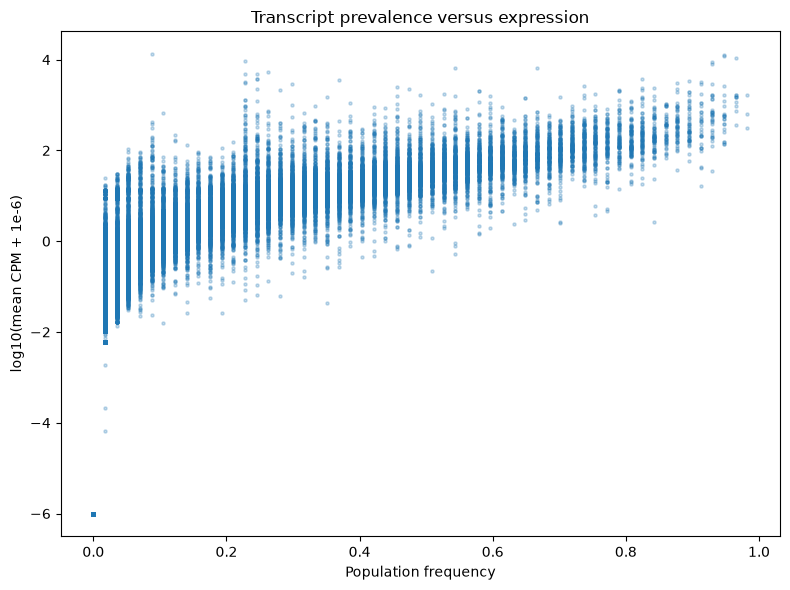

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    summary["population_frequency"],
    np.log10(
        summary["mean_cpm"] + 1e-6
    ),
    s=5,
    alpha=0.25
)

plt.xlabel(
    "Population frequency"
)

plt.ylabel(
    "log10(mean CPM + 1e-6)"
)

plt.title(
    "Transcript prevalence versus expression"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "2_frequency_vs_expression.png",
    dpi=220
)

plt.show()

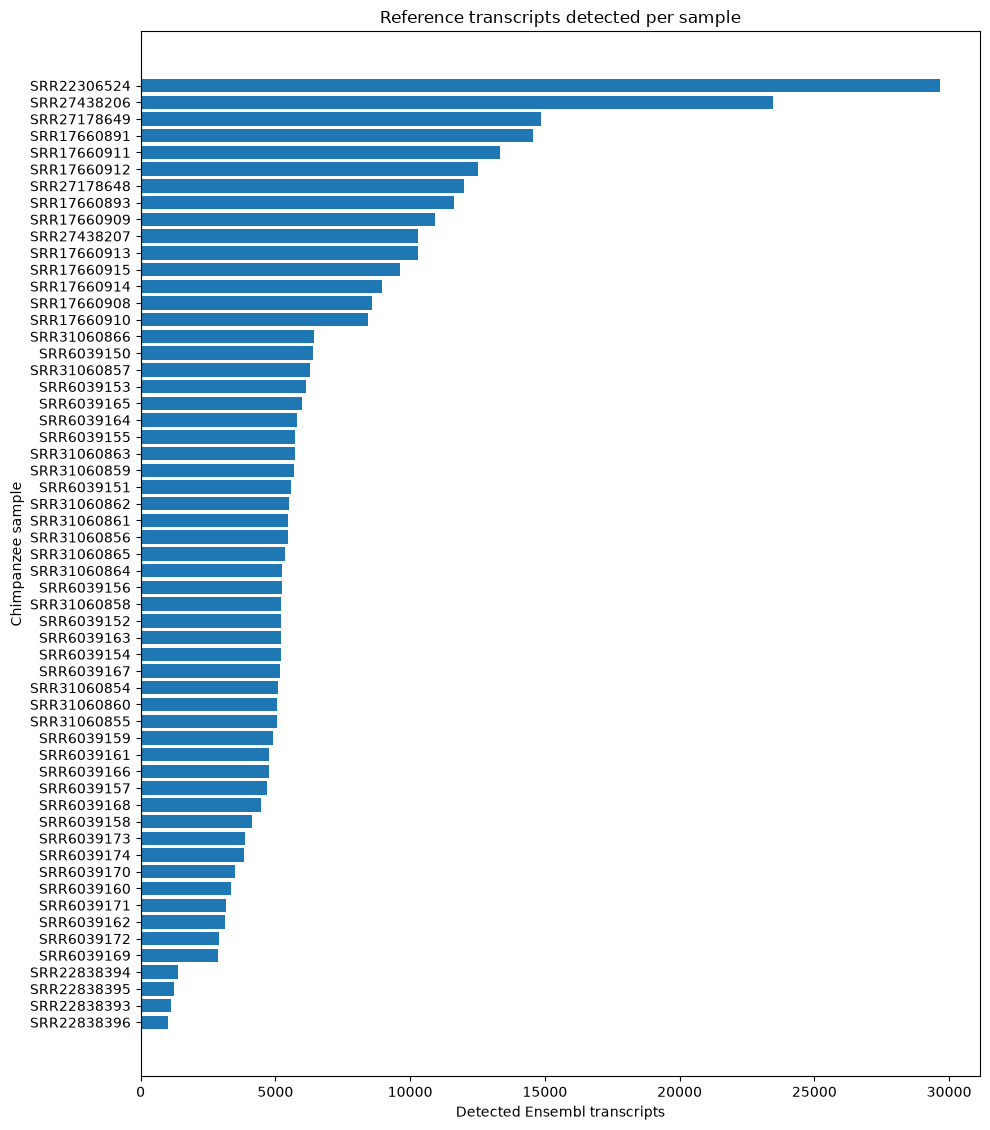

In [37]:
ordered = sample_summary.sort_values(
    "detected_transcripts"
)

plt.figure(
    figsize=(
        10,
        max(7, len(ordered) * 0.2)
    )
)

plt.barh(
    ordered["sample"],
    ordered["detected_transcripts"]
)

plt.xlabel(
    "Detected Ensembl transcripts"
)

plt.ylabel(
    "Chimpanzee sample"
)

plt.title(
    "Reference transcripts detected per sample"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "3_sample_detected_transcripts.png",
    dpi=220
)

plt.show()

In [38]:
class_order = [
    "Not detected",
    "Rare",
    "Low frequency",
    "Intermediate",
    "Common",
    "Core"
]

class_counts = (
    summary["frequency_class"]
    .value_counts()
    .reindex(class_order)
    .fillna(0)
)

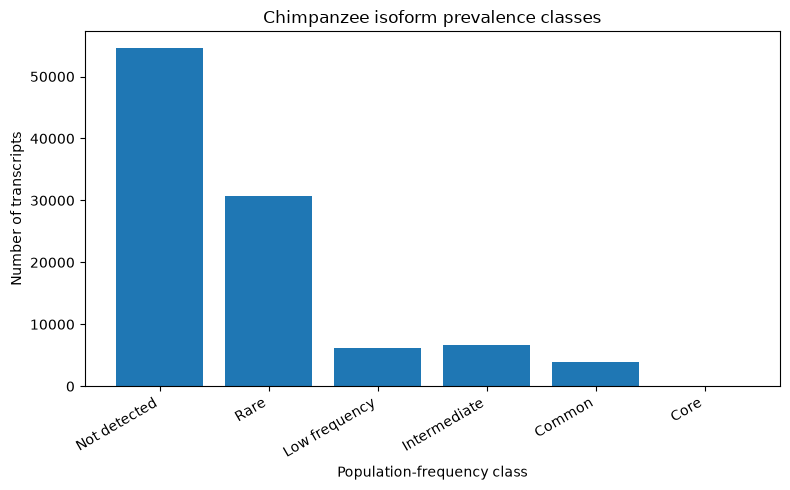

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.ylabel(
    "Number of transcripts"
)

plt.xlabel(
    "Population-frequency class"
)

plt.title(
    "Chimpanzee isoform prevalence classes"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()